# Flood Event Master Table

This notebook builds the **event-level flood modeling dataset** for the Urban Flood Stress workflow.

Core rules:
- The base table is `data/processed/311/flood_events.csv`.
- The canonical street key is `segment_id`.
- The final unit of analysis is **Flood Event**, not individual 311 complaints.
- The positive class means **observed / reported flooding complaint event**.
- Absence of a 311 complaint does **not** prove physical absence of flooding.
- Precipitation is joined by `segment_id -> station_p_id` and temporal overlap.
- Tide is joined by `segment_id -> tide_id` and temporal overlap.
- Census, FEMA, and infrastructure are attached with spatial logic and event-safe aggregation.

Important temporal note:
- The natural dataset is saved in `data/processed/modeling/flood_events_master_table.parquet`.
- A separate balanced dataset is built in `11_balancing.ipynb`.

Event semantics:
- This table is the **natural / unbalanced** event table.
- It preserves reported prevalence and should be used for descriptive analysis, calibration, and unbiased holdout evaluation.
- `storm_event_id` clusters positive events into conservative storm windows using a 6-hour inter-event gap.

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from project_name.flood_events_master import (
    DIAGNOSTICS_DIR,
    MASTER_GEOPARQUET_PATH,
    MASTER_PARQUET_PATH,
    build_master_table,
)
from project_name.flood_event_balancing import VALIDATION_MASTER_PATH

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [2]:
result = build_master_table(write_outputs=True)
master = result.master_table
diagnostics = result.diagnostics

print(f"rows: {len(master):,}")
print(f"unique events: {master['event_id'].nunique():,}")
print(f"unique segments: {master['segment_id'].nunique(dropna=True):,}")
print(f"master parquet: {MASTER_PARQUET_PATH}")
print(f"master geoparquet: {MASTER_GEOPARQUET_PATH}")
print(f"diagnostics dir: {DIAGNOSTICS_DIR}")

rows: 34,870
unique events: 34,870
unique segments: 17,053
master parquet: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/flood_events_master_table.parquet
master geoparquet: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/flood_events_master_table.geoparquet
diagnostics dir: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/diagnostics


## Event Targets and Core Keys

The final target columns are:
- `occurrence`
- `intensity`
- `resolution_hours`
- `resolution_bool`

The event-level geometry comes from the matched `segment_id` line geometry in the LION-derived street layer.

Interpretation:
- `occurrence = True` means the event was observed and reported in 311.
- It does **not** mean all physically flooded segments were reported.
- Unreported plausible flooding is handled separately in the balancing workflow.

In [3]:
display(
    master[
        [
            "event_id",
            "segment_id",
            "event_start_local",
            "event_window_end_local",
            "event_window_duration_hours",
            "occurrence",
            "intensity",
            "resolution_hours",
            "resolution_bool",
            "station_p_id",
            "tide_id",
            "census_geoid",
            "fema_fld_zone",
        ]
    ].head(10)
)

display(diagnostics["validation_checks"])
display(diagnostics["precipitation_diagnostics"])
display(diagnostics["tide_diagnostics"])
display(pd.read_csv(VALIDATION_MASTER_PATH))

,event_id,segment_id,event_start_local,event_window_end_local,event_window_duration_hours,occurrence,intensity,resolution_hours,resolution_bool,station_p_id,tide_id,census_geoid,fema_fld_zone
0,1,100001,2023-11-21 20:38:00,2023-11-22 10:45:00,14.116667,True,1,14.116667,True,USW00094789,8516945,36081049202,X
1,2,100013,2025-02-18 02:29:00,2025-02-19 02:29:00,24.000000,True,1,NaN,False,USW00094789,8516945,36081049202,X
2,3,100014,2020-09-10 05:09:00,2020-09-17 06:35:00,169.433333,True,1,169.433333,True,USW00094789,8516945,36081049202,X
3,4,100018,2016-02-24 10:00:00,2016-02-26 07:10:00,45.166667,True,1,45.166667,True,USW00094789,8516945,36081049200,X
4,5,100048,2010-07-15 13:02:00,2010-07-16 06:30:00,17.466667,True,1,17.466667,True,USW00094789,8516945,36081129102,X
5,6,100060,2022-07-02 02:56:00,2022-07-02 04:20:00,1.400000,True,1,1.400000,True,USW00094789,8516945,36081129102,X
6,7,100064,2023-02-23 03:29:00,2023-02-23 05:30:00,2.016667,True,1,2.016667,True,USW00094789,8516945,36081129103,X
7,8,100066,2013-06-07 19:47:00,2013-06-08 07:45:00,11.966667,True,1,11.966667,True,USW00094789,8516945,36081129103,X
8,9,100097,2017-05-05 09:55:00,2017-05-05 16:50:00,6.916667,True,1,6.916667,True,USW00014732,8516945,36081136700,X
9,10,100097,2023-09-29 06:50:51,2023-09-29 15:50:00,8.985833,True,2,8.985833,True,USW00014732,8516945,36081136700,X


,check,value
0,event_rows,34870
1,duplicate_event_id,0
2,null_segment_id,0
3,null_geometry,0
4,negative_event_window_duration,0
5,negative_resolution_hours,0
6,duplicate_event_signature,0
7,events_missing_prec_station,0
8,events_missing_tide_station,0
9,events_missing_census_geoid,0


,events_total,events_without_station_crosswalk,events_zero_prec_overlap,events_one_prec_overlap,events_multiple_prec_overlap,unmatched_precip_station_ids
0,34870,0,17090,14678,3102,


,events_total,events_without_tide_crosswalk,events_without_tide_observations,unmatched_tide_ids
0,34870,0,2698,


,metric,value
0,rows,34870
1,unique_segments,17053
2,storm_events,117
3,duplicate_event_id,0
4,null_precip_polygon_id,0
5,null_tide_polygon_id,0
6,negative_event_window_duration,0


## Storm Clustering, Join Quality, and Missingness

These diagnostics help audit:
- missing joins,
- null inflation,
- precipitation and tide coverage,
- whether one-row-per-event integrity was preserved,
- and whether the storm clustering is dominated by a few large windows.

In [4]:
display(diagnostics["missingness_report"].head(40))
display(diagnostics["census_diagnostics"])
display(diagnostics["fema_diagnostics"])
display(diagnostics["infrastructure_diagnostics"])

storm_summary_path = DIAGNOSTICS_DIR / "storm_event_summary.csv"
if storm_summary_path.exists():
    display(pd.read_csv(storm_summary_path).sort_values("n_positive_events", ascending=False).head(15))

,column,null_count,null_share,dtype
0,posted_speed,2746,0.078750,float64
1,tide_level_m_max,2698,0.077373,object
2,tide_level_m_mean,2698,0.077373,object
3,tide_level_m_min,2698,0.077373,object
4,tide_level_m_range,2698,0.077373,object
5,street_width_max,2262,0.064870,float64
6,street_width_min,2247,0.064439,float64
7,total_lanes,2244,0.064353,float64
8,census_no_vehicle_share,795,0.022799,float64
9,census_renter_share,795,0.022799,float64


,acs_period,event_rows,joined_rows,null_census_geoid,duplicate_point_matches
0,2007_2011,4846,4846,0,0
1,2008_2012,2113,2113,0,0
2,2009_2013,1611,1611,0,0
3,2010_2014,2372,2372,0,0
4,2011_2015,1722,1722,0,0
5,2012_2016,2029,2029,0,0
6,2013_2017,1963,1963,0,0
7,2016_2020,2013,2013,0,0
8,2017_2021,3313,3313,0,0
9,2018_2022,2868,2868,0,0


,segments_with_intersections,intersection_rows,sfha_segments,segments_outside_nfhl
0,17051,18452,1793,2


,layer,segment_rows,features,null_nearest_distance,status
0,catch_basins,17053.0,154212.0,0.0,NaN
1,outfalls,17053.0,5428.0,0.0,NaN
2,green_infrastructure,NaN,NaN,NaN,not_available


,storm_event_id,storm_start,storm_end,n_positive_events,n_positive_segments,n_boroughs,storm_duration_hours
54,STORM_00055,2020-05-29 15:06:00,2022-10-27 08:15:00,6980,4756,5,21137.150000
52,STORM_00053,2015-05-25 04:19:00,2018-09-11 08:05:00,5049,3501,5,28923.766667
83,STORM_00084,2024-02-07 20:41:00,2025-01-30 03:50:00,2444,1824,5,8575.150000
2,STORM_00003,2011-01-16 20:48:00,2011-12-16 00:30:00,2433,1833,5,7995.700000
1,STORM_00002,2010-01-12 02:30:00,2011-01-15 00:00:00,2358,1806,5,8829.500000
46,STORM_00047,2014-03-26 05:23:00,2014-12-21 01:35:00,1791,1421,5,6476.200000
72,STORM_00073,2023-06-29 15:02:00,2023-11-06 21:15:00,1694,1401,5,3126.216667
98,STORM_00099,2025-03-29 14:38:00,2025-09-21 18:32:00,1418,1162,5,4227.900000
20,STORM_00021,2012-04-16 06:20:00,2012-10-13 08:50:00,1366,1100,5,4322.500000
39,STORM_00040,2013-04-01 02:12:00,2013-11-09 03:45:00,1135,892,5,5329.550000


## Target and Weather Diagnostics

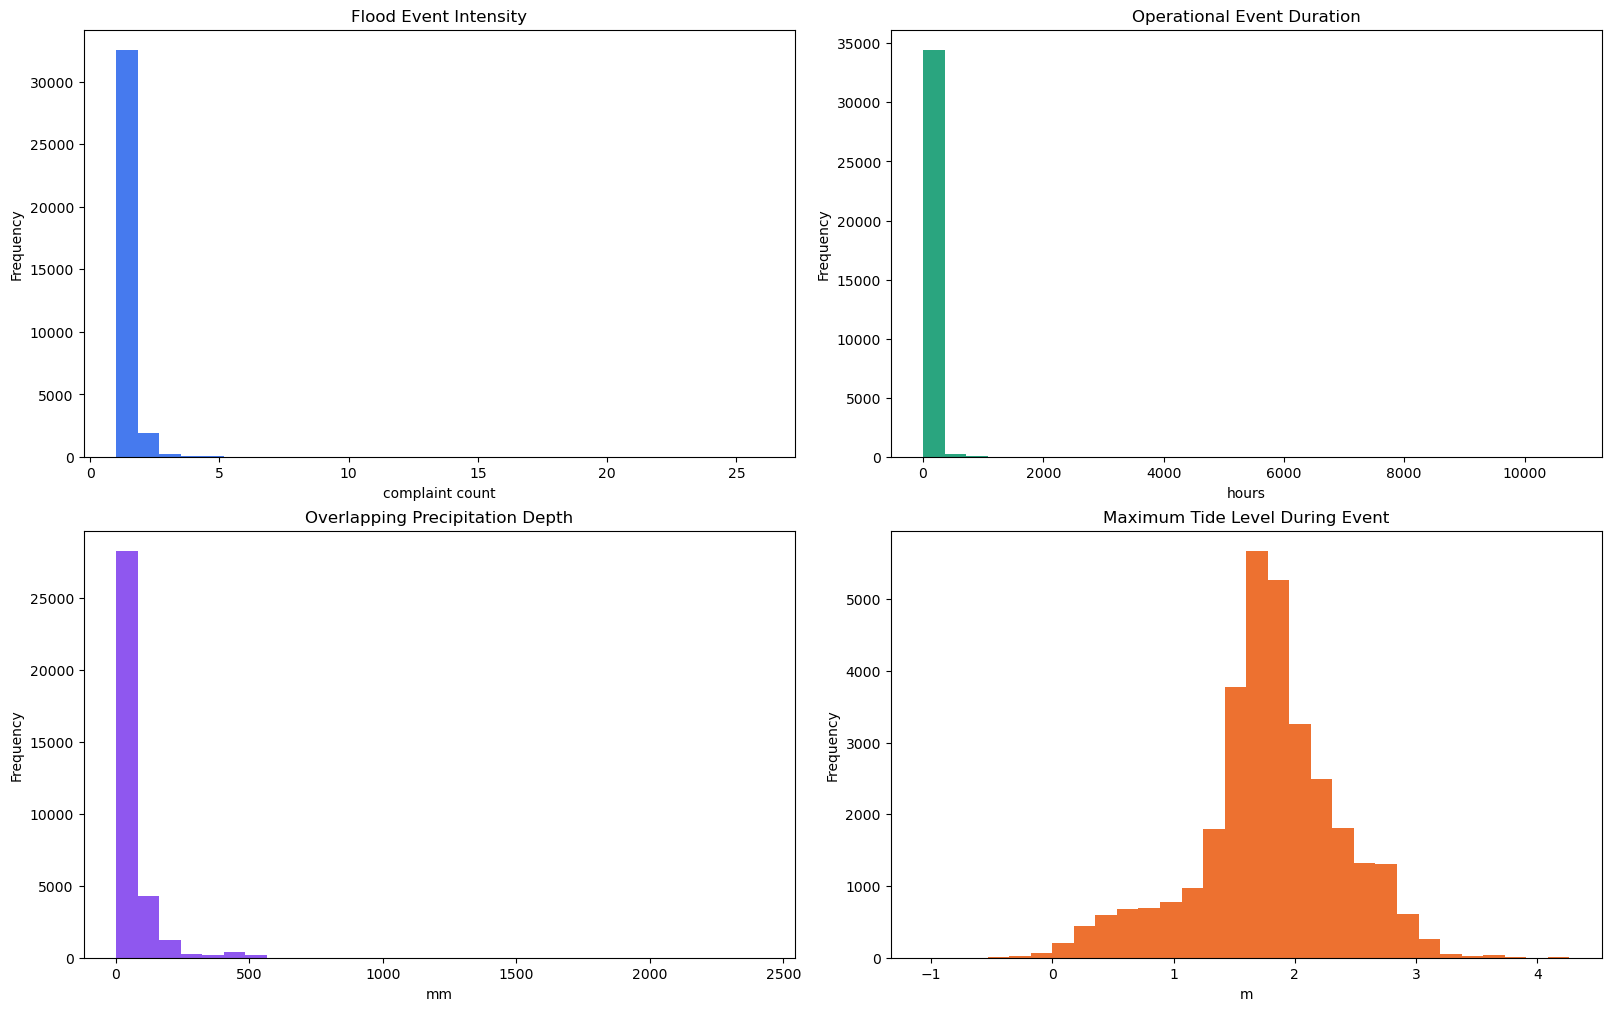

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

intensity_series = pd.to_numeric(master["intensity"], errors="coerce").dropna()
duration_series = pd.to_numeric(master["event_window_duration_hours"], errors="coerce").dropna()
prec_depth_series = pd.to_numeric(master["prec_depth_total"], errors="coerce").dropna()
tide_max_series = pd.to_numeric(master["tide_level_m_max"], errors="coerce").dropna()

intensity_series.plot.hist(ax=axes[0, 0], bins=30, color="#2563EB", alpha=0.85)
axes[0, 0].set_title("Flood Event Intensity")
axes[0, 0].set_xlabel("complaint count")

duration_series.plot.hist(ax=axes[0, 1], bins=30, color="#059669", alpha=0.85)
axes[0, 1].set_title("Operational Event Duration")
axes[0, 1].set_xlabel("hours")

prec_depth_series.plot.hist(ax=axes[1, 0], bins=30, color="#7C3AED", alpha=0.85)
axes[1, 0].set_title("Overlapping Precipitation Depth")
axes[1, 0].set_xlabel("mm")

tide_max_series.plot.hist(ax=axes[1, 1], bins=30, color="#EA580C", alpha=0.85)
axes[1, 1].set_title("Maximum Tide Level During Event")
axes[1, 1].set_xlabel("m")

plt.show()

## Spatial QA/QC

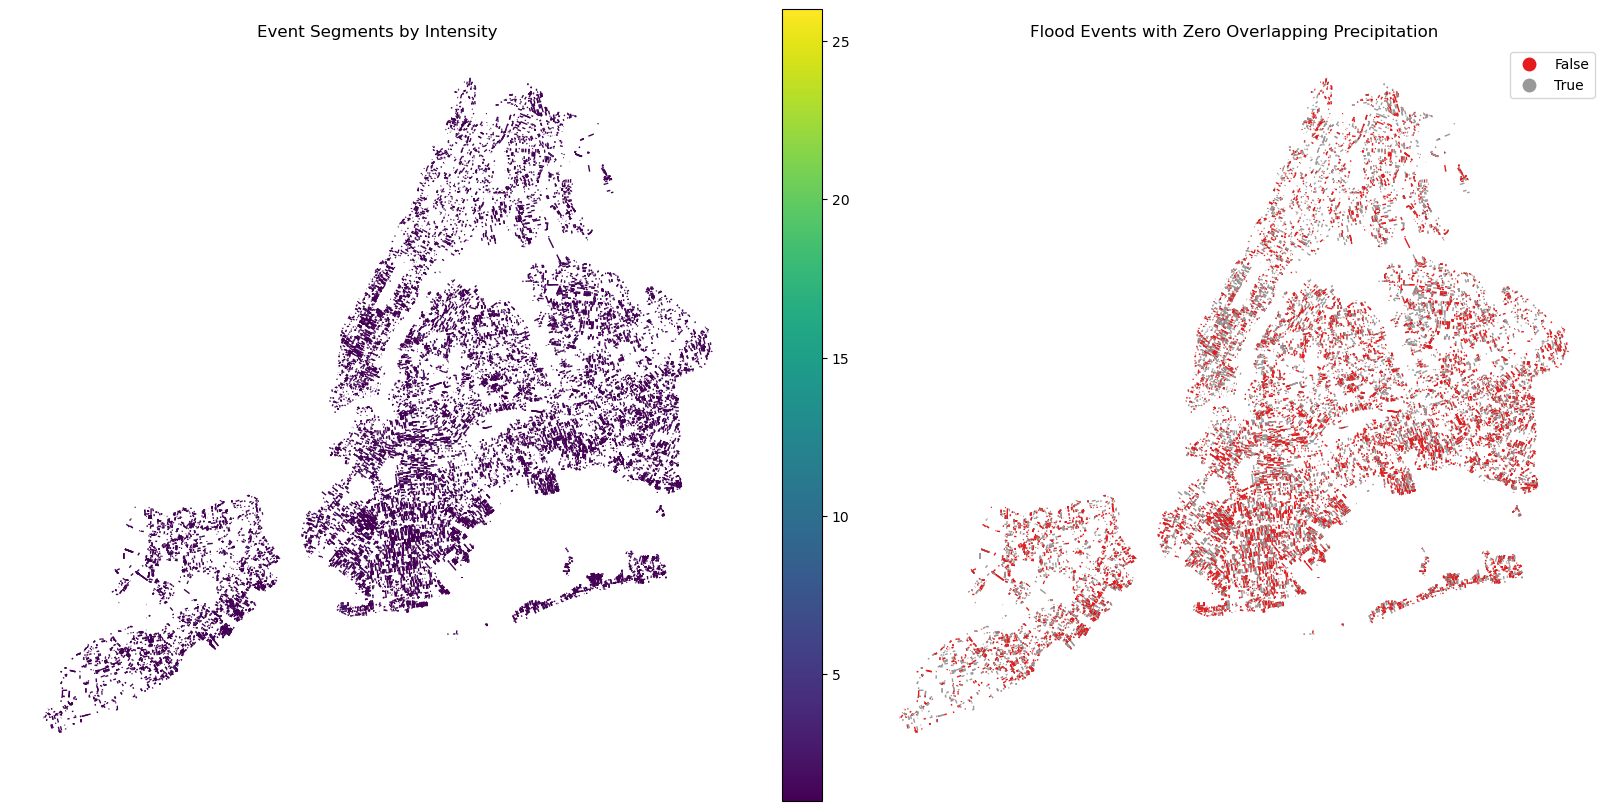

In [6]:
plot_frame = master
if not isinstance(plot_frame, gpd.GeoDataFrame):
    plot_frame = gpd.read_parquet(MASTER_GEOPARQUET_PATH)
    plot_frame = gpd.GeoDataFrame(plot_frame, geometry="geometry")

if plot_frame.crs is None:
    plot_frame = plot_frame.set_crs(2263)

plot_frame = plot_frame.to_crs(2263).copy()
plot_frame["zero_precip"] = plot_frame["n_prec"].eq(0)
plot_frame["intensity_num"] = pd.to_numeric(plot_frame["intensity"], errors="coerce").fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

plot_frame.plot(ax=axes[0], column="intensity_num", linewidth=1.0, legend=True, cmap="viridis")
axes[0].set_title("Event Segments by Intensity")
axes[0].set_axis_off()

plot_frame.plot(ax=axes[1], column="zero_precip", linewidth=1.0, legend=True, categorical=True, cmap="Set1")
axes[1].set_title("Flood Events with Zero Overlapping Precipitation")
axes[1].set_axis_off()

plt.show()

## Saved Outputs

The build step writes:
- `data/processed/modeling/flood_events_master_table.parquet`
- `data/processed/modeling/flood_events_master_table.geoparquet`
- CSV diagnostics in `data/processed/modeling/diagnostics/`

Use `11_balancing.ipynb` to build:
- matched negative controls,
- the balanced training table,
- and the separate possible-unreported-flood diagnostic layer.

In [7]:
display(master.head(5))
display(diagnostics["numeric_summary"].head(30))
display(diagnostics["correlation_summary"].head(30))

,event_id,start,end,duration_hours,segment_id,n_complaints,status,event_start_local,event_end_local,event_window_end_local,event_window_duration_hours,event_end_observed_local,resolution_hours,resolution_bool,event_end_inferred,occurrence,intensity,event_year,event_month,event_date,flood_event_status,resolution,geometry,street_name,street_name_safe,street_feature_type,street_segment_type,street_traffic_direction,LBoro,RBoro,posted_speed,street_width_min,street_width_max,travel_lanes,park_lanes,total_lanes,bike_lane,edge_id,road_class,segment_speed_heuristic_mph,segment_speed_mph,segment_length_ft,segment_travel_time_s,u,v,segment_edge_betweenness,segment_borough_left,segment_borough_right,segment_borough,segment_length_geom_ft,dem_min,dem_max,dem_mean,dem_sd,dem_start,dem_end,dem_slope,elevation_processed,component_id,component_size,in_largest_component,is_bridge_segment,connectivity_processed,node_in_degree_u,node_out_degree_u,node_total_degree_u,node_betweenness_u,node_component_id_u,node_component_size_u,node_in_largest_component_u,node_is_articulation_u,node_in_degree_v,node_out_degree_v,node_total_degree_v,node_betweenness_v,node_component_id_v,node_component_size_v,node_in_largest_component_v,node_is_articulation_v,node_in_degree_mean,node_in_degree_max,node_out_degree_mean,node_out_degree_max,node_total_degree_mean,node_total_degree_max,node_betweenness_mean,node_betweenness_max,node_articulation_any,shore_id,shore_graph_steps,shore_processed,shore_seed_edge,station_p_id,tide_id,event_x,event_y,event_lon,event_lat,complaint_count_check,complaint_spatial_match_count,complaint_textual_match_count,complaint_borough_mode,fema_fld_zone,fema_zone_subty,fema_overlap_ft,fema_overlap_share,fema_zone_count,fema_sfha_any,catch_basin_nearest_ft,catch_basin_count_100ft,catch_basin_count_250ft,outfall_nearest_ft,outfall_count_250ft,outfall_count_500ft,census_geoid,census_borough,census_poverty_rate,census_renter_share,census_no_vehicle_share,census_median_household_income,census_acs_period,census_acs_year,census_tiger_year,census_geography_base,prec_station_link_count,n_prec,prec_intensity_max,prec_intensity_mean,prec_depth_total,prec_duration_total,tide_id_dynamic,tide_obs_n,tide_level_m_mean,tide_level_m_max,tide_level_m_min,tide_level_m_range,complaint_count_mismatch,prec_match_class
0,1,2023-11-21 20:38:00,2023-11-22 10:45:00,14.116667,100001,1,1,2023-11-21 20:38:00,2023-11-22 10:45:00,2023-11-22 10:45:00,14.116667,2023-11-22 10:45:00,14.116667,True,False,True,1,2023,11,2023-11-21,1,14.116667,"MULTILINESTRING ((1051660.831 201881.444, 1052...",208 STREET,,0,U,A,4.0,4.0,11.176,30.0,32.0,1,2,3.0,,132004,local,10.0,11.176,213.305957,19.086073,95858,100175,2859835.0,QUEENS,QUEENS,QUEENS,699.822694,19.280012,22.540003,20.910007,1.629995,22.540003,19.280012,0.015283,True,0,102370,True,False,True,2,3,5,3100822.0,0,102370,True,False,3,3,6,4852022.0,0,102370,True,False,2.5,3,3.0,3,5.5,6,3976422.0,4852022.0,False,8531680,189.0,True,False,USW00094789,8516945,1.051661e+06,201881.443607,-73.756811,40.720537,1,1,0,QUEENS,X,AREA OF MINIMAL FLOOD HAZARD,699.822694,1.0,1,False,13.500714,10,22,3565.874864,0,0,36081049202,Queens,0.195868,0.242574,0.087459,108053.0,2019_2023,2023.0,2023.0,census_2020_geography,1,1,3.288066,3.288066,52.609055,16.0,8516945,14,1.871711,3.094939,0.648005,2.446934,False,single
1,2,2025-02-18 02:29:00,NaT,NaN,100013,1,0,2025-02-18 02:29:00,NaT,2025-02-19 02:29:00,24.000000,NaT,NaN,False,False,True,1,2025,2,2025-02-18,0,NaN,"MULTILINESTRING ((1051731.517 202810.628, 1051...",HILLSIDE AVENUE,,0,U,T,4.0,4.0,11.176,70.0,70.0,4,2,6.0,,119019,local,15.0,11.176,89.757458,8.031269,90257,90258,67119833.0,QUEENS,QUEENS,QUEENS,294.479850,30.999998,32.079994,31.539997,0.539998,30.999998,32.079994,0.012032,True,0,102370,True,False,True,3,2,5,67214572.0,0,102370,True,False,3,4,7,149957821.0,0,102370,True,False,3.0,3,3.0,4,6.0,7,108586196.5,149957821.0,False,8531680,190.0,True,False,USW00094789,8516945,1.051732e+06,202810.627951,-73.756

,feature,count,mean,std,min,5%,25%,50%,75%,95%,max
0,event_id,34870.0,17435.5,10066.24628,1.0,1744.45,8718.25,17435.5,26152.75,33126.55,34870.0
1,duration_hours,34542.0,41.55542,183.909594,0.0,0.15,2.783333,16.0,31.0125,141.838083,10745.116667
2,n_complaints,34870.0,1.09458,0.504534,1.0,1.0,1.0,1.0,1.0,2.0,26.0
3,status,34870.0,0.995125,0.096865,0.0,1.0,1.0,1.0,1.0,1.0,2.0
4,event_window_duration_hours,34870.0,41.390344,183.051834,0.0,0.166667,2.833333,16.233333,30.033333,141.425833,10745.116667
5,resolution_hours,34542.0,41.555478,183.911026,0.0,0.15,2.783333,16.0,31.0125,141.833333,10745.116667
6,intensity,34870.0,1.09458,0.504534,1.0,1.0,1.0,1.0,1.0,2.0,26.0
7,event_year,34870.0,2018.27657,5.15271,2010.0,2010.0,2014.0,2020.0,2023.0,2025.0,2026.0
8,event_month,34870.0,6.543447,3.264817,1.0,1.0,4.0,7.0,9.0,12.0,12.0
9,flood_event_status,34870.0,0.995125,0.096865,0.0,1.0,1.0,1.0,1.0,1.0,2.0


,feature,target,pearson_r
0,resolution_hours,event_window_duration_hours,1.000000
1,resolution,event_window_duration_hours,1.000000
2,duration_hours,event_window_duration_hours,1.000000
3,tide_obs_n,event_window_duration_hours,0.999529
4,n_prec,event_window_duration_hours,0.893647
5,prec_duration_total,event_window_duration_hours,0.675532
6,prec_depth_total,event_window_duration_hours,0.441649
7,prec_intensity_max,event_window_duration_hours,0.162448
8,complaint_count_check,event_window_duration_hours,0.143790
9,complaint_spatial_match_count,event_window_duration_hours,0.143790
